In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU 사용 가능 여부:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU 사용 가능 여부: True
GPU 이름: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/AI_Final_Project"

print(os.path.exists(BASE_DIR))
print(os.listdir(BASE_DIR))

True
['data', 'notebooks', 'results', 'real_test']


In [ ]:
import os
from torchvision.datasets import OxfordIIITPet

BASE_DIR = "/content/drive/MyDrive/AI_Final_Project"
DATA_DIR = os.path.join(BASE_DIR, "data")

# Oxford-IIIT Pet Dataset 다운로드
dataset = OxfordIIITPet(
    root=DATA_DIR,
    split="trainval",
    target_types="category",
    download=True
)

print("전체 이미지 수:", len(dataset))
print("클래스 수:", len(dataset.classes))
print(dataset.classes)

100%|██████████| 792M/792M [00:40<00:00, 19.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.9MB/s]


전체 이미지 수: 3680
클래스 수: 37
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [ ]:
print(dataset.classes)

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [ ]:
print("전체 이미지 수:", len(dataset))
print("클래스 수:", len(dataset.classes))

전체 이미지 수: 3680
클래스 수: 37


In [ ]:
from collections import Counter

labels = [label for _, label in dataset]
count = Counter(labels)

for idx, class_name in enumerate(dataset.classes):
    if class_name in [
        "Bengal",
        "Maine Coon",
        "Persian",
        "Ragdoll",
        "British Shorthair"
    ]:
        print(class_name, ":", count[idx])

Bengal : 100
British Shorthair : 100
Maine Coon : 100
Persian : 100
Ragdoll : 100


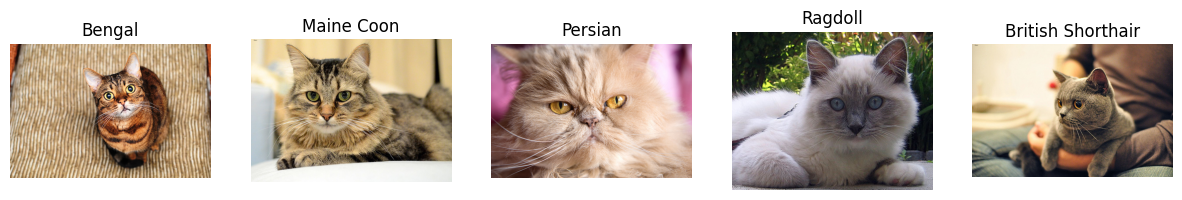

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

target_classes = [
    "Bengal",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "British Shorthair"
]

for ax, class_name in zip(axes, target_classes):

    idx = dataset.classes.index(class_name)

    for i in range(len(dataset)):
        img, label = dataset[i]

        if label == idx:
            ax.imshow(img)
            ax.set_title(class_name)
            ax.axis("off")
            break

plt.show()

In [ ]:
dataset[0]

(<PIL.Image.Image image mode=RGB size=394x500>, 0)

In [ ]:
target_classes = [
    "Bengal",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "British Shorthair"
]

target_class_to_original_idx = {
    class_name: dataset.classes.index(class_name)
    for class_name in target_classes
}

target_original_indices = list(target_class_to_original_idx.values())

print(target_class_to_original_idx)
print(target_original_indices)

{'Bengal': 5, 'Maine Coon': 20, 'Persian': 23, 'Ragdoll': 26, 'British Shorthair': 9}
[5, 20, 23, 26, 9]


In [ ]:
for class_name in target_classes:
    idx = dataset.classes.index(class_name)

    count = 0

    for _, label in dataset:
        if label == idx:
            count += 1

    print(class_name, count)

Bengal 100
Maine Coon 100
Persian 100
Ragdoll 100
British Shorthair 100


In [ ]:
from torch.utils.data import Subset

# 5개 품종에 해당하는 이미지만 골라내기
selected_indices = []

for i in range(len(dataset)):
    _, label = dataset[i]

    if label in target_original_indices:
        selected_indices.append(i)

selected_dataset = Subset(dataset, selected_indices)

print("선택된 이미지 수:", len(selected_dataset))

선택된 이미지 수: 500


In [ ]:
from torch.utils.data import random_split

train_size = int(0.8 * len(selected_dataset))
val_size = len(selected_dataset) - train_size

train_dataset, val_dataset = random_split(
    selected_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("학습 데이터 수:", len(train_dataset))
print("검증 데이터 수:", len(val_dataset))

학습 데이터 수: 400
검증 데이터 수: 100


In [ ]:
img, label = dataset[0]

print(type(img))
print(img.size)
print(label)

<class 'PIL.Image.Image'>
(394, 500)
0


In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
from torch.utils.data import Dataset

In [ ]:
class TransformDataset(Dataset):
    def __init__(self, subset, transform=None, target_classes=None):
        self.subset = subset
        self.transform = transform
        self.target_classes = target_classes

        self.original_to_new_label = {
            dataset.classes.index(class_name): new_idx
            for new_idx, class_name in enumerate(target_classes)
        }

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]

        if self.transform:
            image = self.transform(image)

        new_label = self.original_to_new_label[label]

        return image, new_label

In [ ]:
train_dataset_tf = TransformDataset(
    train_dataset,
    transform=train_transform,
    target_classes=target_classes
)

val_dataset_tf = TransformDataset(
    val_dataset,
    transform=val_transform,
    target_classes=target_classes
)

print("학습 데이터 수:", len(train_dataset_tf))
print("검증 데이터 수:", len(val_dataset_tf))

학습 데이터 수: 400
검증 데이터 수: 100


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset_tf,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset_tf,
    batch_size=32,
    shuffle=False
)

print("Train batch 수:", len(train_loader))
print("Validation batch 수:", len(val_loader))

Train batch 수: 13
Validation batch 수: 4


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(target_classes))

model = model.to(device)

print(model.fc)
print("사용 장치:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 87.2MB/s]


Linear(in_features=512, out_features=5, bias=True)
사용 장치: cuda


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
num_epochs = 10

train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Train
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset_tf)
    epoch_train_acc = running_corrects.double() / len(train_dataset_tf)

    # Validation
    model.eval()
    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset_tf)
    epoch_val_acc = val_corrects.double() / len(val_dataset_tf)

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc.item())
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc.item())

    print(f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}")
    print(f"Val   Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")
    print("-" * 40)

Epoch 1/10
Train Loss: 0.7454 Acc: 0.7225
Val   Loss: 2.8759 Acc: 0.6000
----------------------------------------
Epoch 2/10
Train Loss: 0.4108 Acc: 0.8650
Val   Loss: 2.3888 Acc: 0.5900
----------------------------------------
Epoch 3/10
Train Loss: 0.3559 Acc: 0.8775
Val   Loss: 3.1318 Acc: 0.5000
----------------------------------------
Epoch 4/10
Train Loss: 0.1797 Acc: 0.9375
Val   Loss: 0.6190 Acc: 0.8100
----------------------------------------
Epoch 5/10
Train Loss: 0.1861 Acc: 0.9500
Val   Loss: 0.3601 Acc: 0.9000
----------------------------------------
Epoch 6/10
Train Loss: 0.1417 Acc: 0.9475
Val   Loss: 0.4670 Acc: 0.8300
----------------------------------------
Epoch 7/10
Train Loss: 0.1278 Acc: 0.9475
Val   Loss: 0.7866 Acc: 0.7700
----------------------------------------
Epoch 8/10
Train Loss: 0.0887 Acc: 0.9675
Val   Loss: 0.6489 Acc: 0.8200
----------------------------------------
Epoch 9/10
Train Loss: 0.1292 Acc: 0.9600
Val   Loss: 0.7432 Acc: 0.8100
---------------

In [ ]:
import torch

torch.save(model.state_dict(),
           "/content/drive/MyDrive/AI_Final_Project/results/cat_model_last.pth")

print("저장 완료!")

저장 완료!


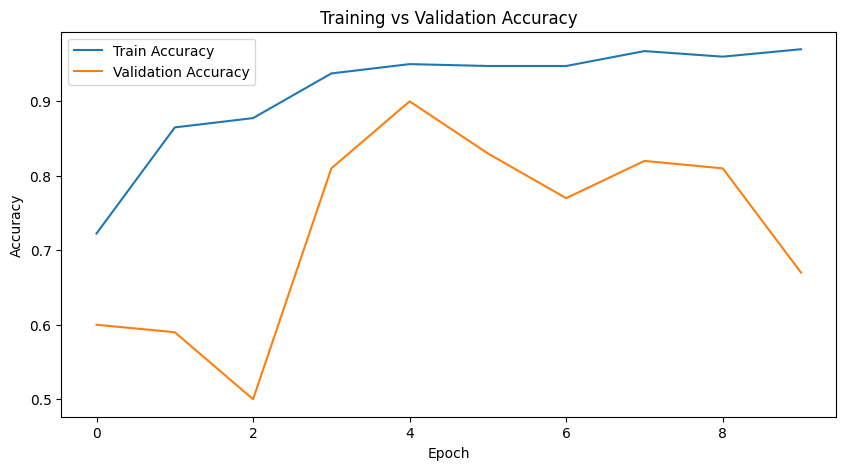

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
best_val_acc = 0.0
best_epoch = 0

In [ ]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(target_classes))

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
num_epochs = 10

train_acc_history = []
val_acc_history = []
train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):

    print(f"Epoch {epoch+1}/{num_epochs}")

    # ==========================
    # Train
    # ==========================

    model.train()

    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset_tf)
    epoch_train_acc = running_corrects.double() / len(train_dataset_tf)

    # ==========================
    # Validation
    # ==========================

    model.eval()

    val_loss = 0.0
    val_corrects = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            val_loss += loss.item() * images.size(0)
            val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = val_loss / len(val_dataset_tf)
    epoch_val_acc = val_corrects.double() / len(val_dataset_tf)

    # ==========================
    # Best Model 저장
    # ==========================

    if epoch_val_acc > best_val_acc:

        best_val_acc = epoch_val_acc
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/AI_Final_Project/results/best_cat_model.pth"
        )

        print(f"🔥 Best Model 저장! Epoch {best_epoch}")

    # ==========================
    # History 저장
    # ==========================

    train_loss_history.append(epoch_train_loss)
    train_acc_history.append(epoch_train_acc.item())

    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc.item())

    print(f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}")
    print(f"Val   Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

    print("-" * 40)

print()
print("🏆 Best Epoch:", best_epoch)
print("🏆 Best Validation Accuracy:", best_val_acc)

Epoch 1/10
🔥 Best Model 저장! Epoch 1
Train Loss: 0.7406 Acc: 0.7575
Val   Loss: 12.7053 Acc: 0.3900
----------------------------------------
Epoch 2/10
🔥 Best Model 저장! Epoch 2
Train Loss: 0.3470 Acc: 0.8650
Val   Loss: 1.4526 Acc: 0.6300
----------------------------------------
Epoch 3/10
🔥 Best Model 저장! Epoch 3
Train Loss: 0.2489 Acc: 0.9200
Val   Loss: 2.3736 Acc: 0.6600
----------------------------------------
Epoch 4/10
🔥 Best Model 저장! Epoch 4
Train Loss: 0.2305 Acc: 0.9200
Val   Loss: 1.1524 Acc: 0.6900
----------------------------------------
Epoch 5/10
Train Loss: 0.2154 Acc: 0.9325
Val   Loss: 1.1279 Acc: 0.6800
----------------------------------------
Epoch 6/10
🔥 Best Model 저장! Epoch 6
Train Loss: 0.1540 Acc: 0.9500
Val   Loss: 0.6429 Acc: 0.8100
----------------------------------------
Epoch 7/10
🔥 Best Model 저장! Epoch 7
Train Loss: 0.1028 Acc: 0.9600
Val   Loss: 0.5134 Acc: 0.9100
----------------------------------------
Epoch 8/10
Train Loss: 0.0587 Acc: 0.9875
Val   Los

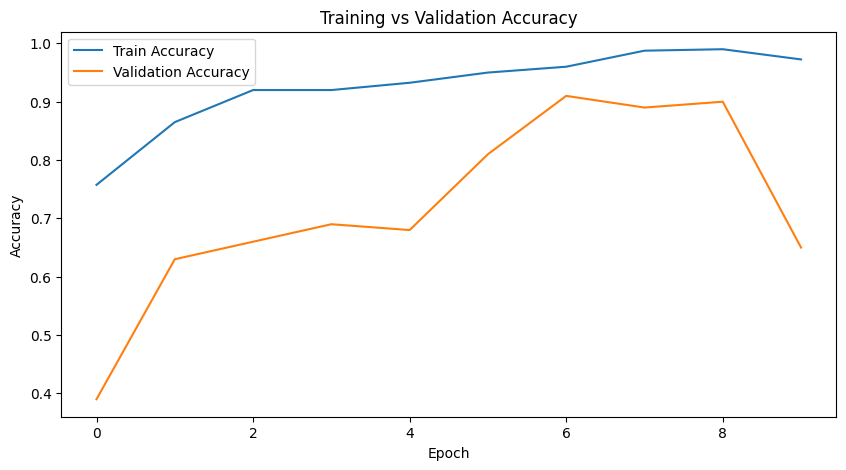

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_acc_history, label="Train Accuracy")
plt.plot(val_acc_history, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

In [ ]:
# 클래스 이름

class_names = [
    "Bengal",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "British Shorthair"
]

# 모델 불러오기

model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/AI_Final_Project/results/best_cat_model.pth"
    )
)

model = model.to(device)

model.eval()

print("모델 로드 완료!")

모델 로드 완료!


In [ ]:
import os

real_test_path = "/content/drive/MyDrive/AI_Final_Project/real_test"

print(os.listdir(real_test_path))

['hongsi.jpg']


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 홍시 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/hongsi.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: British Shorthair
🎯 최고 확률: 60.36%

📊 품종별 확률
Bengal: 0.32%
Maine Coon: 0.37%
Persian: 14.55%
Ragdoll: 24.39%
British Shorthair: 60.36%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 마루 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/maru.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: Bengal
🎯 최고 확률: 95.02%

📊 품종별 확률
Bengal: 95.02%
Maine Coon: 1.48%
Persian: 0.47%
Ragdoll: 1.32%
British Shorthair: 1.72%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 약콩 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/kong.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: British Shorthair
🎯 최고 확률: 41.17%

📊 품종별 확률
Bengal: 4.33%
Maine Coon: 0.48%
Persian: 32.35%
Ragdoll: 21.67%
British Shorthair: 41.17%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 평안 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/an.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: Ragdoll
🎯 최고 확률: 98.99%

📊 품종별 확률
Bengal: 0.06%
Maine Coon: 0.04%
Persian: 0.58%
Ragdoll: 98.99%
British Shorthair: 0.34%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 라떼 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/latte.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: Ragdoll
🎯 최고 확률: 41.29%

📊 품종별 확률
Bengal: 3.69%
Maine Coon: 0.73%
Persian: 30.04%
Ragdoll: 41.29%
British Shorthair: 24.25%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 모카 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/mocha.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: Ragdoll
🎯 최고 확률: 89.80%

📊 품종별 확률
Bengal: 0.02%
Maine Coon: 0.16%
Persian: 9.16%
Ragdoll: 89.80%
British Shorthair: 0.86%


In [ ]:
from PIL import Image
import torch
import torch.nn.functional as F

# 모카2 사진 경로
image_path = "/content/drive/MyDrive/AI_Final_Project/real_test/mocha2.jpg"

# 이미지 불러오기
image = Image.open(image_path).convert("RGB")

# 전처리
input_tensor = val_transform(image).unsqueeze(0).to(device)

# 예측
with torch.no_grad():
    outputs = model(input_tensor)

    probabilities = F.softmax(outputs, dim=1)

    probs, preds = torch.max(probabilities, 1)

predicted_class = class_names[preds.item()]

print("🐱 예측 품종:", predicted_class)
print("🎯 최고 확률:", f"{probs.item()*100:.2f}%")

print("\n📊 품종별 확률")

for i, class_name in enumerate(class_names):
    print(
        f"{class_name}: {probabilities[0][i].item()*100:.2f}%"
    )

🐱 예측 품종: Ragdoll
🎯 최고 확률: 99.96%

📊 품종별 확률
Bengal: 0.00%
Maine Coon: 0.00%
Persian: 0.04%
Ragdoll: 99.96%
British Shorthair: 0.00%


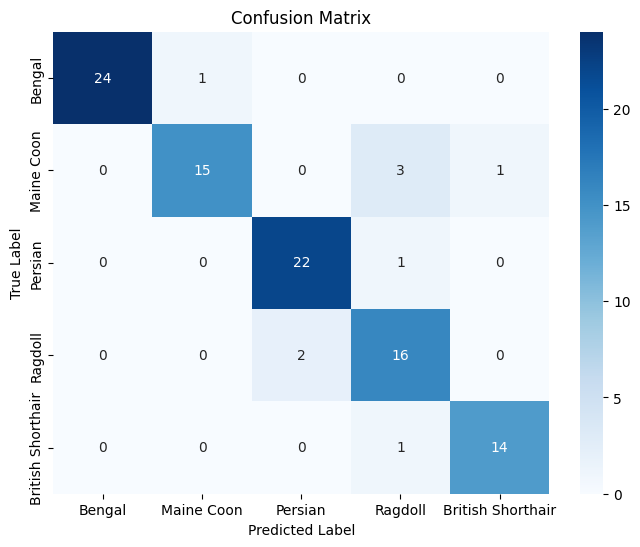

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 실제값, 예측값 저장
y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Confusion Matrix 생성
cm = confusion_matrix(y_true, y_pred)

# 시각화
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()